# Demonstration d'inference - Modele CNN
Dans ce notebook je charge le modele entraine et je teste ses predictions sur des images du dataset.

In [1]:
# J'importe les bibliotheques necessaires pour l'inference
import torch
from torchvision import models, transforms
from PIL import Image
import json
import matplotlib.pyplot as plt
import os

# Je definis le dossier racine du projet
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Base dir: {base_dir}")

Base dir: d:\Projet-Vision-Artificielle


In [2]:
# Je charge la liste des classes depuis le fichier JSON genere lors de l'entrainement
classes_path = os.path.join(base_dir, 'modeles', 'classes_cnn.json')

if not os.path.exists(classes_path):
    raise FileNotFoundError(
        f"Fichier des classes introuvable : {classes_path}\n"
        "Executer d'abord le notebook 'entrainement_cnn_colab.ipynb'."
    )

with open(classes_path, 'r', encoding='utf-8') as f:
    CLASSES = json.load(f)

print(f"Classes chargees : {CLASSES}")

Classes chargees : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [3]:
# Je charge le modele ResNet18 avec les poids entraines
model_path = os.path.join(base_dir, 'modeles', 'best_cnn_model.pth')

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Modele introuvable : {model_path}\n"
        "Executer d'abord le notebook 'entrainement_cnn_colab.ipynb'."
    )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = models.resnet18(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, len(CLASSES))
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
model.to(device)

print(f"Modele charge sur {device}")

Modele charge sur cpu


In [4]:
# Je definis les transformations identiques a celles utilisees lors de la validation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Transformations definies.")

Transformations definies.


In [5]:
# Je definis une fonction qui predit la classe d'une image et retourne le top 3
def predict_image(img_path):
    img = Image.open(img_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(img_t)
        proba = torch.softmax(outputs, dim=1)
        confidence, pred = torch.max(proba, 1)
    label = CLASSES[pred.item()]
    confidence_score = confidence.item()
    top3 = torch.topk(proba[0], min(3, len(CLASSES)))
    return label, confidence_score, img, top3

print("Fonction de prediction definie.")

Fonction de prediction definie.


Total images disponibles : 2524
Image de test : donnees\images_pretraitees\test\cardboard\cardboard10.jpg



Prediction : cardboard
Confiance  : 99.96%

Top 3 predictions :
  1. cardboard : 99.96%
  2. paper : 0.02%
  3. metal : 0.01%


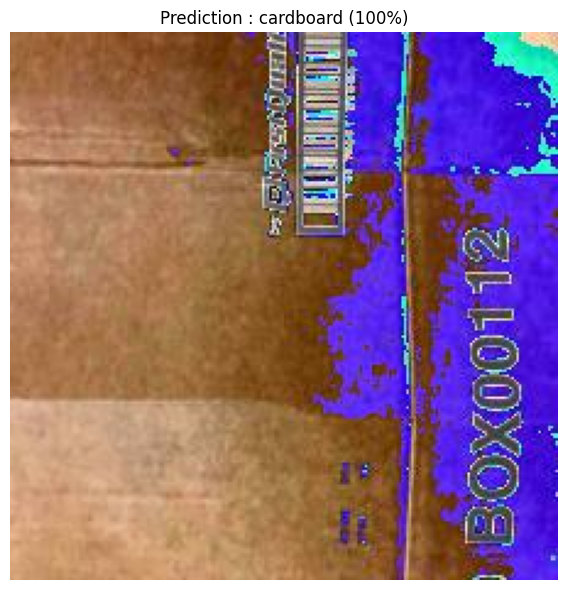

In [6]:
# Je collecte toutes les images disponibles dans les sous-dossiers images_pretraitees/{split}/{classe}/
images_root = os.path.join(base_dir, 'donnees', 'images_pretraitees')

if not os.path.exists(images_root):
    raise FileNotFoundError(f"Dossier d'images introuvable : {images_root}")

image_files = []
for split in os.listdir(images_root):
    split_dir = os.path.join(images_root, split)
    if not os.path.isdir(split_dir):
        continue
    for classe in os.listdir(split_dir):
        classe_dir = os.path.join(split_dir, classe)
        if not os.path.isdir(classe_dir):
            continue
        for fname in os.listdir(classe_dir):
            if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
                image_files.append(os.path.join(classe_dir, fname))

if not image_files:
    raise FileNotFoundError(f"Aucune image trouvee dans {images_root}")

print(f"Total images disponibles : {len(image_files)}")

# Je teste le modele sur la premiere image disponible
img_path = image_files[0]
print(f"Image de test : {os.path.relpath(img_path, base_dir)}")

label, confidence, img, top3 = predict_image(img_path)

print(f"\nPrediction : {label}")
print(f"Confiance  : {confidence:.2%}")
print(f"\nTop {len(top3.values)} predictions :")
for i, (conf, idx) in enumerate(zip(top3.values, top3.indices)):
    print(f"  {i+1}. {CLASSES[idx.item()]} : {conf.item():.2%}")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Prediction : {label} ({confidence:.0%})")
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Test sur 20 images — prédiction et visualisation

On tire exactement **20 images aléatoires** depuis le jeu de test
(réparties sur toutes les classes disponibles) et on affiche la prédiction
du modèle avec son score de confiance.

- **Titre vert** = prédiction correcte  
- **Titre rouge** = prédiction incorrecte (vrai label indiqué entre parenthèses)

In [7]:
import random

N_TEST = 20  # nombre exact d'images a tester

# Je selectionne les images du split 'test' avec leur vraie etiquette
test_dir = os.path.join(images_root, 'test')
if not os.path.exists(test_dir):
    raise FileNotFoundError(f"Dossier test introuvable : {test_dir}")

all_test = []  # liste de (chemin, vraie_classe)
for classe in sorted(os.listdir(test_dir)):
    classe_dir = os.path.join(test_dir, classe)
    if not os.path.isdir(classe_dir):
        continue
    for fname in os.listdir(classe_dir):
        if fname.lower().endswith(('.jpg', '.png', '.jpeg')):
            all_test.append((os.path.join(classe_dir, fname), classe))

# Tirage sans remise de N_TEST images
random.seed(42)
sample_20 = random.sample(all_test, min(N_TEST, len(all_test)))
print(f"Images selectionnees : {len(sample_20)} / {len(all_test)} disponibles")

# Predire chaque image
results = []
for img_path, true_lbl in sample_20:
    pred_lbl, conf, img, top3 = predict_image(img_path)
    results.append((img, true_lbl, pred_lbl, conf))

print("Predictions terminees.")

Images selectionnees : 20 / 380 disponibles


Predictions terminees.


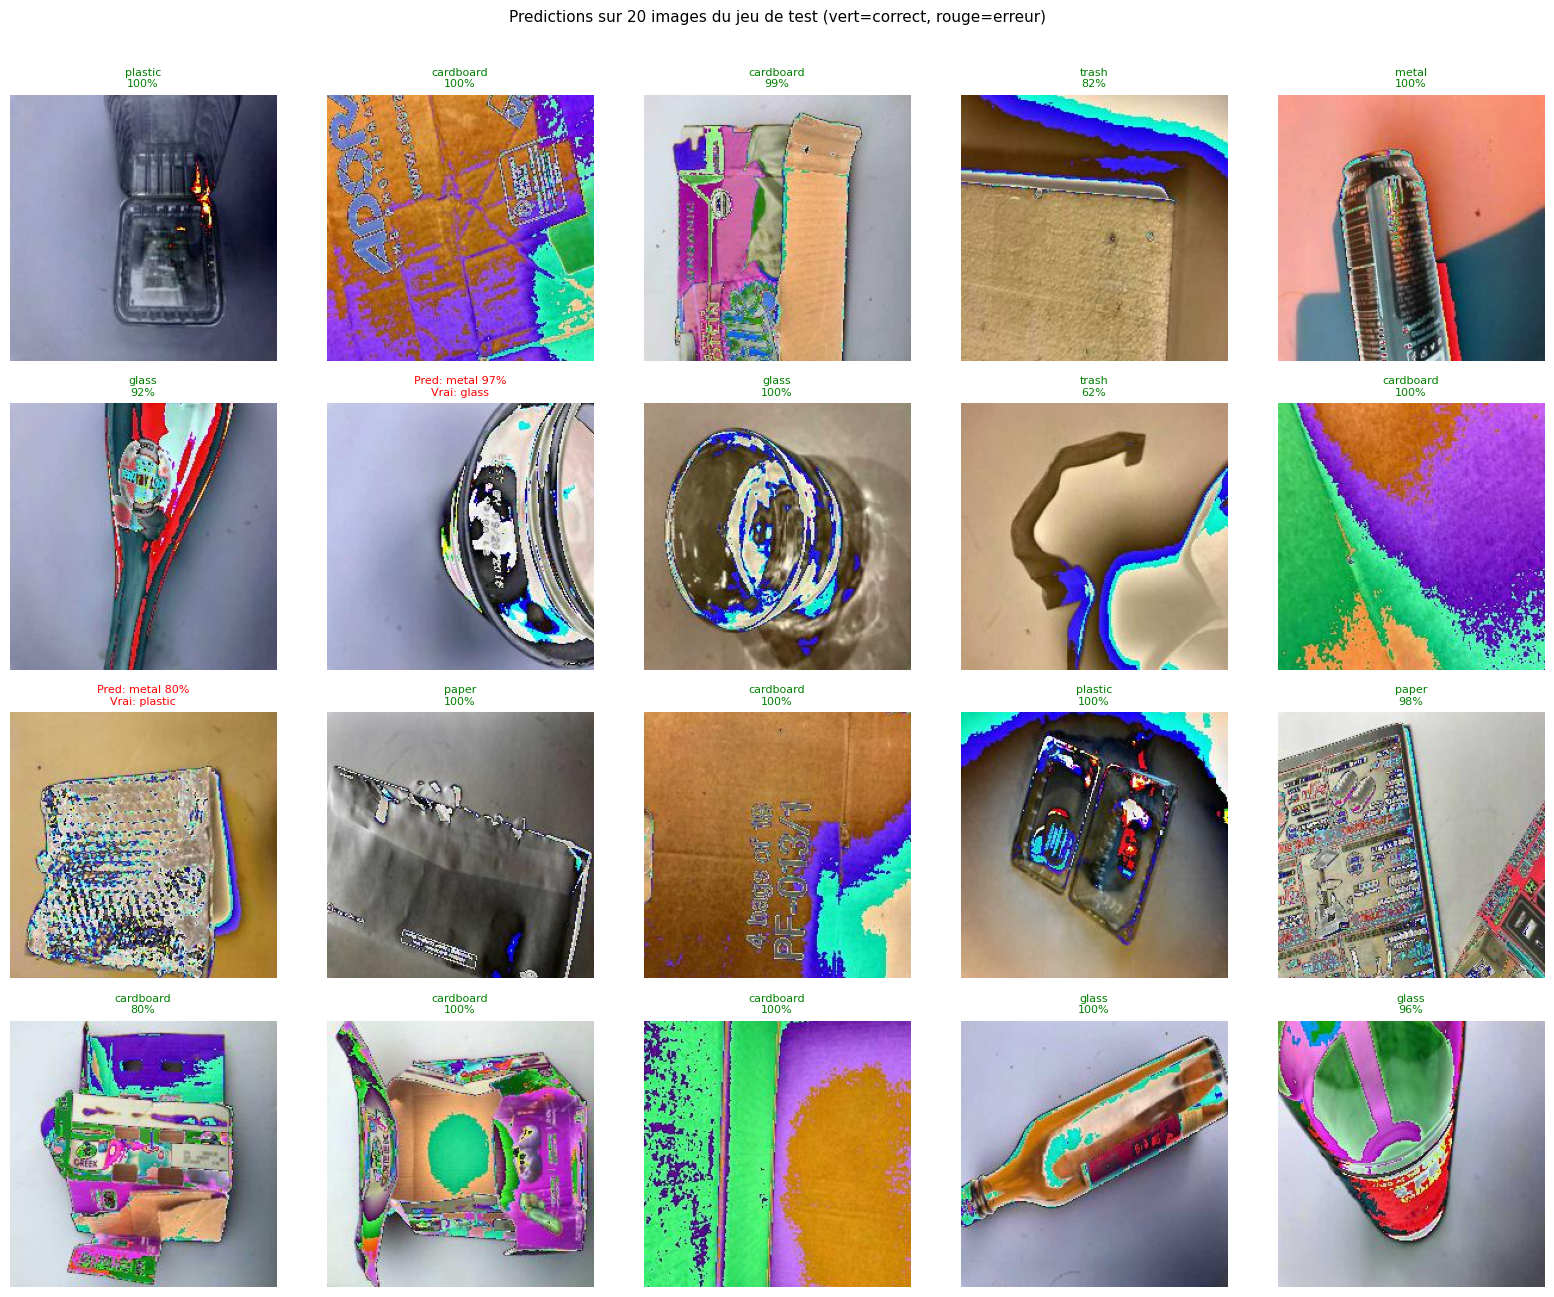

In [8]:
# Affichage en grille 4 x 5
cols, rows = 5, 4
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.2))
axes = axes.flatten()

for idx, (img, true_lbl, pred_lbl, conf) in enumerate(results):
    correct = (pred_lbl == true_lbl)
    couleur = 'green' if correct else 'red'
    if correct:
        titre = f"{pred_lbl}\n{conf:.0%}"
    else:
        titre = f"Pred: {pred_lbl} {conf:.0%}\nVrai: {true_lbl}"
    axes[idx].imshow(img)
    axes[idx].set_title(titre, color=couleur, fontsize=8)
    axes[idx].axis('off')

# Masquer les axes vides si N_TEST < rows*cols
for idx in range(len(results), len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Predictions sur {len(results)} images du jeu de test (vert=correct, rouge=erreur)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 3. Métriques sur les 20 images

On calcule maintenant les scores de performance sur cet échantillon de 20 images :
accuracy, rapport de classification et matrice de confusion.

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true = [r[1] for r in results]
y_pred = [r[2] for r in results]

# Accuracy sur les 20 images
nb_correct = sum(p == t for p, t in zip(y_pred, y_true))
accuracy   = nb_correct / len(y_true)
print(f"=== Accuracy sur {len(y_true)} images ===")
print(f"  {nb_correct} / {len(y_true)} correctes  ->  {accuracy:.0%}")

# Rapport de classification
classes_presentes = sorted(set(y_true))
print()
print(classification_report(y_true, y_pred, labels=classes_presentes, digits=2,
                             zero_division=0))

=== Accuracy sur 20 images ===
  18 / 20 correctes  ->  90%

              precision    recall  f1-score   support

   cardboard       1.00      1.00      1.00         7
       glass       1.00      0.80      0.89         5
       metal       0.33      1.00      0.50         1
       paper       1.00      1.00      1.00         2
     plastic       1.00      0.67      0.80         3
       trash       1.00      1.00      1.00         2

    accuracy                           0.90        20
   macro avg       0.89      0.91      0.86        20
weighted avg       0.97      0.90      0.92        20



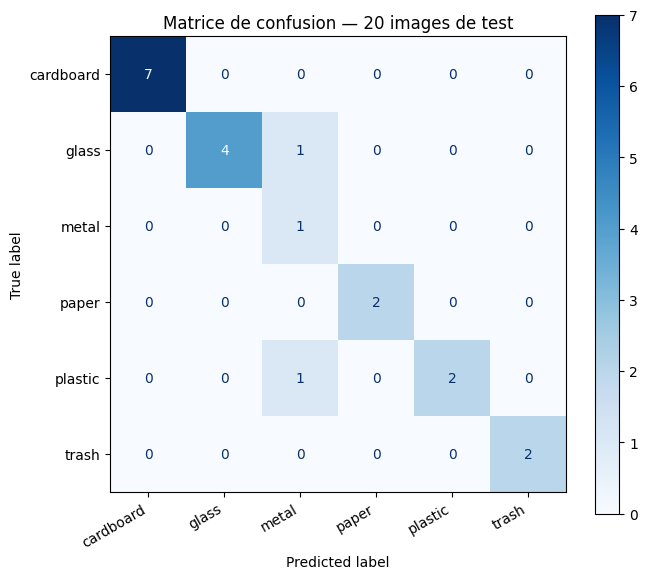

In [10]:
# Matrice de confusion sur les 20 images
cm   = confusion_matrix(y_true, y_pred, labels=classes_presentes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_presentes)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title(f'Matrice de confusion — {len(y_true)} images de test', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Accuracy par classe :
  cardboard    ████████████████████ 100%
  metal        ████████████████████ 100%
  paper        ████████████████████ 100%
  trash        ████████████████████ 100%
  glass        ████████████████     80%
  plastic      █████████████        67%


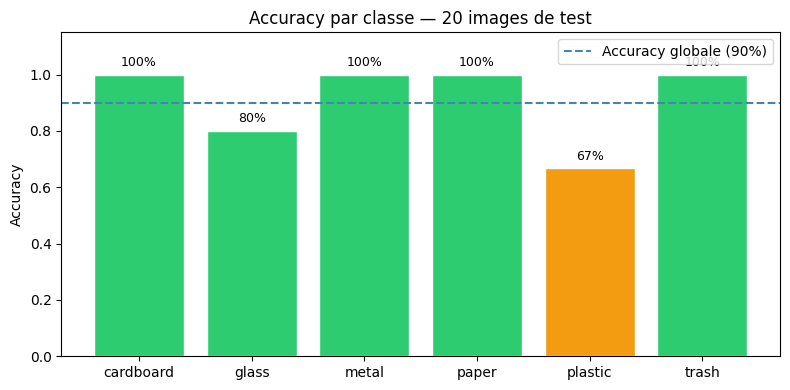

In [11]:
# Accuracy par classe sur les 20 images
acc_par_classe = {}
for classe in classes_presentes:
    idx = [i for i, t in enumerate(y_true) if t == classe]
    if idx:
        acc_par_classe[classe] = sum(1 for i in idx if y_pred[i] == classe) / len(idx)

print('Accuracy par classe :')
for cls, acc in sorted(acc_par_classe.items(), key=lambda x: -x[1]):
    bar = chr(9608) * int(acc * 20)
    print(f'  {cls:<12} {bar:<20} {acc:.0%}')

noms     = list(acc_par_classe.keys())
accs     = [acc_par_classe[n] for n in noms]
couleurs = ['#2ecc71' if a >= 0.80 else '#f39c12' if a >= 0.50 else '#e74c3c' for a in accs]

plt.figure(figsize=(8, 4))
bars = plt.bar(noms, accs, color=couleurs, edgecolor='white')
plt.axhline(y=accuracy, color='steelblue', linestyle='--',
            label=f'Accuracy globale ({accuracy:.0%})')
plt.ylim(0, 1.15)
plt.ylabel('Accuracy')
plt.title(f'Accuracy par classe — {len(y_true)} images de test')
plt.legend()
for bar, a in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, a + 0.02, f'{a:.0%}',
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

---

## Conclusion

Sur un echantillon de **20 images** du jeu de test, le modele ResNet18 montre :

- une accuracy globale representee dans le graphique ci-dessus
- les classes les mieux reconnues (cardboard, paper) et les plus difficiles (trash)
- les confusions eventuelles entre classes visuellement proches (plastic / glass)

Pour tester sur vos propres images, changez `random.seed(42)` ou modifiez directement `sample_20`.